<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-5-Thermodynamics/Untitled171.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Geodesics for the Ideal Monoatomic gas**

The metric in log coordinates is
$$
\tilde{g}(x, y) =
\begin{pmatrix}
e^{2x} + \frac{9}{4} + e^{2(x+y)} & \frac{15}{4} + e^{2(x+y)} \\
\frac{15}{4} + e^{2(x+y)} & e^{2y} + \frac{25}{4} + e^{2(x+y)}
\end{pmatrix}.
$$
Next we plot geodesics in this metric in the $(x, y)$-plane.

Epoch 0, Loss = 1.445536
Epoch 500, Loss = 1.407645
Epoch 1000, Loss = 1.407643
Epoch 1500, Loss = 1.407641
Epoch 2000, Loss = 1.408759
Epoch 2500, Loss = 1.407635
Epoch 3000, Loss = 1.407628
Epoch 3500, Loss = 1.407593
Epoch 4000, Loss = 1.407576
Epoch 4500, Loss = 1.407589


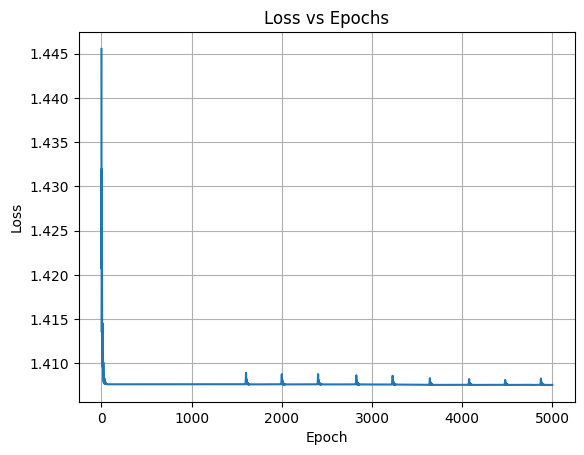

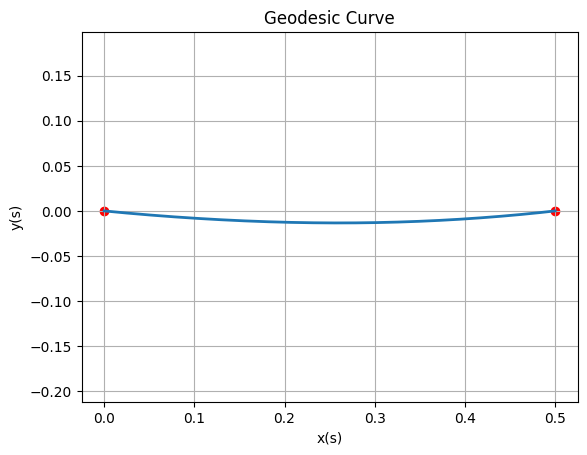

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Boundary conditions
# -----------------------------
x0, y0 = 0.0, 0.0
x1, y1 = 0.50, 0.0

# -----------------------------
# Neural network
# -----------------------------
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(164, activation='tanh'),
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(2)  # outputs nn1, nn2
    ])

model = build_model()

# -----------------------------
# Hard embedding
# -----------------------------
def gamma_theta(s):
    nn = model(s)
    x = (1 - s) * x0 + s * x1 + s * (1 - s) * nn[:, 0:1]
    y = (1 - s) * y0 + s * y1 + s * (1 - s) * nn[:, 1:2]
    return x, y

# -----------------------------
# Metric components
# -----------------------------
def metric(x, y):
    u = x + y
    E = tf.exp(2*x) + 9.0/4.0 + tf.exp(2*u)
    F = 15.0/4.0 + tf.exp(2*u)
    G = tf.exp(2*y) + 25.0/4.0 + tf.exp(2*u)
    return E, F, G

# -----------------------------
# Energy loss
# -----------------------------
def loss_fn(s):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(s)
        x, y = gamma_theta(s)

    dx = tape.gradient(x, s)
    dy = tape.gradient(y, s)

    E, F, G = metric(x, y)

    integrand = E * dx**2 + 2 * F * dx * dy + G * dy**2

    return tf.reduce_mean(integrand)

# -----------------------------
# Training setup
# -----------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

@tf.function
def train_step(s):
    with tf.GradientTape() as tape:
        loss = loss_fn(s)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# -----------------------------
# Training loop
# -----------------------------
epochs = 5000
N = 400
s_train = tf.linspace(0.0, 1.0, N)
s_train = tf.reshape(s_train, (-1, 1))

loss_hist = []

for ep in range(epochs):
    loss = train_step(s_train)
    loss_hist.append(float(loss.numpy()))

    if ep % 500 == 0:
        print(f"Epoch {ep}, Loss = {loss.numpy():.6f}")

# -----------------------------
# Plot loss
# -----------------------------
plt.figure()
plt.plot(loss_hist)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.grid()
plt.show()

# -----------------------------
# Plot geodesic curve
# -----------------------------
s_plot = tf.linspace(0.0, 1.0, 300)
s_plot = tf.reshape(s_plot, (-1, 1))

x_pred, y_pred = gamma_theta(s_plot)

x_pred = x_pred.numpy().flatten()
y_pred = y_pred.numpy().flatten()

plt.figure()
plt.plot(x_pred, y_pred, linewidth=2)
plt.scatter([x0, x1], [y0, y1], color='red')
plt.xlabel("x(s)")
plt.ylabel("y(s)")
plt.title("Geodesic Curve")
plt.grid()
plt.axis('equal')
plt.show()

Next we draw several geodesics joining th eorigin with 8 points along the unit circle.

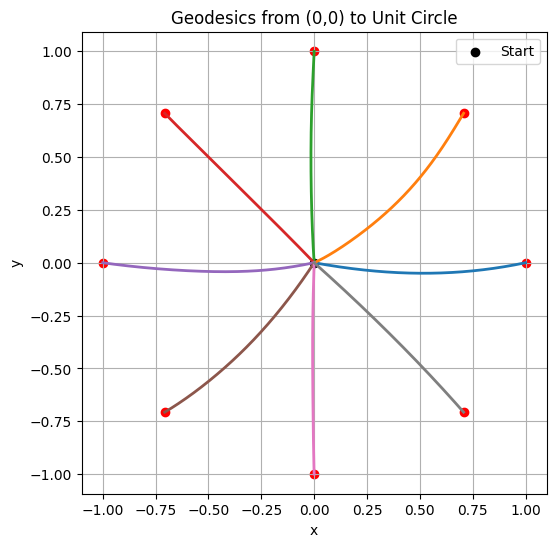

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Fixed starting point
# -----------------------------
x0, y0 = 0.0, 0.0

# -----------------------------
# Points on unit circle
# -----------------------------
num_points = 8
angles = np.linspace(0, 2*np.pi, num_points, endpoint=False)
targets = [(np.cos(a), np.sin(a)) for a in angles]

# -----------------------------
# Metric
# -----------------------------
def metric(x, y):
    u = x + y
    E = tf.exp(2*x) + 9.0/4.0 + tf.exp(2*u)
    F = 15.0/4.0 + tf.exp(2*u)
    G = tf.exp(2*y) + 25.0/4.0 + tf.exp(2*u)
    return E, F, G

# -----------------------------
# Build model
# -----------------------------
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(2)
    ])

# -----------------------------
# Train one geodesic
# -----------------------------
def train_geodesic(x1, y1):

    model = build_model()

    def gamma_theta(s):
        nn = model(s)
        x = (1 - s) * x0 + s * x1 + s * (1 - s) * nn[:, 0:1]
        y = (1 - s) * y0 + s * y1 + s * (1 - s) * nn[:, 1:2]
        return x, y

    def loss_fn(s):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(s)
            x, y = gamma_theta(s)

        dx = tape.gradient(x, s)
        dy = tape.gradient(y, s)

        E, F, G = metric(x, y)

        integrand = E * dx**2 + 2 * F * dx * dy + G * dy**2

        return tf.reduce_mean(integrand)

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    @tf.function
    def train_step(s):
        with tf.GradientTape() as tape:
            loss = loss_fn(s)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss

    # training
    epochs = 3000
    N = 200
    s_train = tf.linspace(0.0, 1.0, N)
    s_train = tf.reshape(s_train, (-1, 1))

    for ep in range(epochs):
        train_step(s_train)

    return model

# -----------------------------
# Plot all geodesics
# -----------------------------
plt.figure(figsize=(6,6))

for (x1, y1) in targets:

    model = train_geodesic(x1, y1)

    def gamma_theta(s):
        nn = model(s)
        x = (1 - s) * x0 + s * x1 + s * (1 - s) * nn[:, 0:1]
        y = (1 - s) * y0 + s * y1 + s * (1 - s) * nn[:, 1:2]
        return x, y

    s_plot = tf.linspace(0.0, 1.0, 200)
    s_plot = tf.reshape(s_plot, (-1, 1))

    x_pred, y_pred = gamma_theta(s_plot)

    plt.plot(x_pred.numpy(), y_pred.numpy(), linewidth=2)

# Plot endpoints (unit circle)
circle_x = [p[0] for p in targets]
circle_y = [p[1] for p in targets]

plt.scatter(circle_x, circle_y, color='red')
plt.scatter([x0], [y0], color='black', label='Start')

plt.title("Geodesics from (0,0) to Unit Circle")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.grid()
plt.legend()
plt.show()

# **Geodesics for the van der Waals fluid**

In the following, we fix the initial point $(V_0, P_0)=(1, 1)$  and plot the geodesics for various values of the parameters $a$ and $b$. We also display the Gaussian curvature $K(P,V)$, together with its logarithmic magnitude $\ln|K(P,V)|$, which highlights more clearly the curves along which the curvature vanishes.

The geodesics are approximated using a neural network of the form
$$
NN(\theta; s) = \gamma_{\theta}(s) = \big(P_{\theta}(s),\, V_{\theta}(s)\big),
$$
with boundary conditions embedded directly into the parametrization:
\begin{align*}
P_{\theta}(s) &= (1-s) P_0 + s P_1 + s(1-s)\, nn^1_{\theta}(s), \\
V_{\theta}(s) &= (1-s) V_0 + s V_1 + s(1-s)\, nn^2_{\theta}(s).
\end{align*}

The endpoints $(P_1, V_1)$ are chosen on a circle of radius $r=0.5$ centered at $(P_0, V_0) = (1,1)$, allowing us to visualize the behavior of neighboring geodesics emanating radially from the same point.

We may consider the following cases of monoatomic gases:

**Argon:** $a=1.355$ and $b = 0.032$

**Neon:** $a=0.213$ and $b = 0.017$

**Krypton:** $a=2.3$ and $b = 0.039$

**Xenon:** $a=4.2$ and $b = 0.051$

Epoch 0, Loss = 64.036224
Epoch 500, Loss = 23.990391
Epoch 1000, Loss = 23.458857
Epoch 1500, Loss = 22.986616
Epoch 2000, Loss = 22.545181
Epoch 2500, Loss = 22.437695
Epoch 3000, Loss = 22.358355


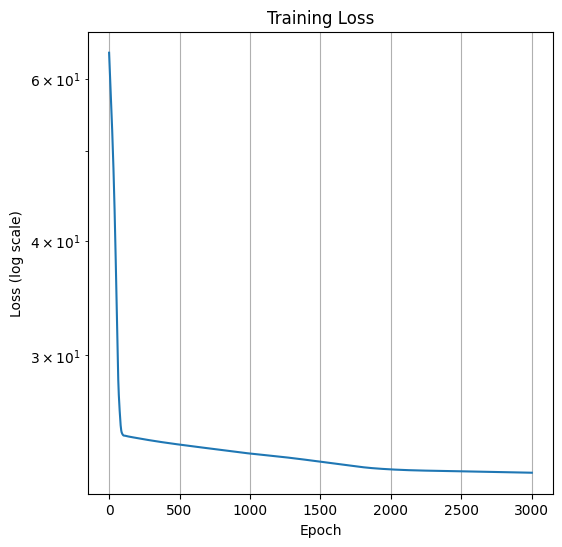

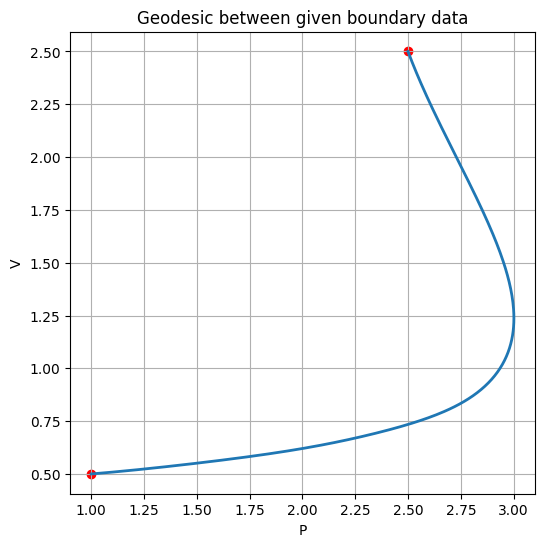

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters (van der Waals)
# -----------------------------
a = 4.2
b = 0.051

# -----------------------------
# Boundary points
# -----------------------------
P0, V0 = 1.0, 0.5
P1, V1 = 2.5, 2.5

# -----------------------------
# Metric
# -----------------------------
def metric(P, V):

    Q = P + a / V**2

    S_P = 3.0 / (2.0 * Q)
    S_V = -3.0 * a / (V**3 * Q) + 5.0 / (2.0 * (V - b))

    T_P = V - b
    T_V = Q - 2.0 * a * (V - b) / V**3

    E = 1 + S_P**2 + T_P**2
    F = S_P * S_V + T_P * T_V
    G = 1 + S_V**2 + T_V**2

    return E, F, G

# -----------------------------
# Model
# -----------------------------
def build_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(2)
    ])

model = build_model()

# -----------------------------
# Hard embedding (boundary)
# -----------------------------
def gamma_theta(s):
    nn = model(s)
    P = (1 - s) * P0 + s * P1 + s * (1 - s) * nn[:, 0:1]
    V = (1 - s) * V0 + s * V1 + s * (1 - s) * nn[:, 1:2]
    return P, V

# -----------------------------
# Loss (energy functional)
# -----------------------------
def loss_fn(s):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(s)
        P, V = gamma_theta(s)

    dP = tape.gradient(P, s)
    dV = tape.gradient(V, s)

    E, F, G = metric(P, V)

    integrand = E * dP**2 + 2 * F * dP * dV + G * dV**2

    return tf.reduce_mean(integrand)

# -----------------------------
# Training
# -----------------------------
optimizer = tf.keras.optimizers.Adam(5e-4)

@tf.function
def train_step(s):
    with tf.GradientTape() as tape:
        loss = loss_fn(s)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# grid
s_train = tf.linspace(0.0, 1.0, 200)
s_train = tf.reshape(s_train, (-1, 1))

# training loop
epochs = 3001
loss_hist = []

for ep in range(epochs):
    loss = train_step(s_train)
    loss_hist.append(float(loss.numpy()))

    if ep % 500 == 0:
        print(f"Epoch {ep}, Loss = {loss.numpy():.6f}")

# -----------------------------
# Plot loss (log scale)
# -----------------------------
plt.figure(figsize=(6,6))
plt.plot(loss_hist)
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Training Loss")
plt.grid()
plt.show()

# -----------------------------
# Plot geodesic
# -----------------------------
s_plot = tf.linspace(0.0, 1.0, 300)
s_plot = tf.reshape(s_plot, (-1, 1))

P_pred, V_pred = gamma_theta(s_plot)

plt.figure(figsize=(6,6))
plt.plot(P_pred.numpy(), V_pred.numpy(), linewidth=2)

plt.scatter([P0, P1], [V0, V1], color='red')
plt.xlabel("P")
plt.ylabel("V")
plt.title("Geodesic between given boundary data")
plt.axis('equal')
plt.grid()
plt.show()

The contour plot of the Gaussian curvature and of $\ln |K|$. In the graph of $\ln |K|$ we notice the zero-curvature lines.

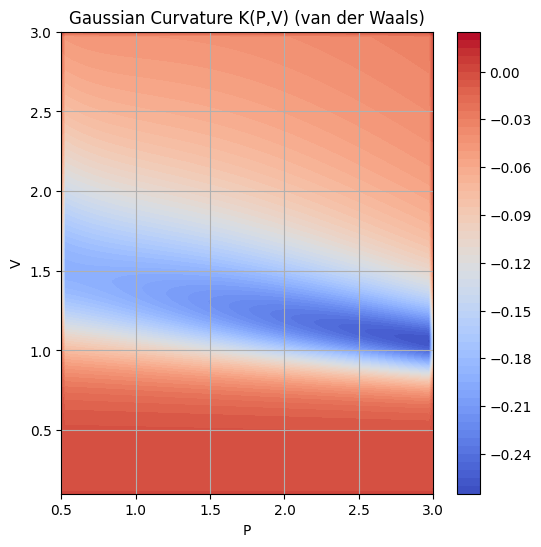

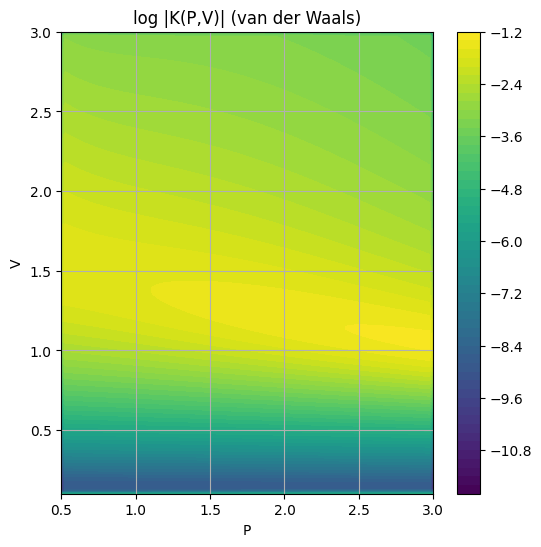

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
a = 4.2

b = 0.051

# -----------------------------
# Grid (avoid V ≈ b)
# -----------------------------
P_vals = np.linspace(0.5, 3.0, 200)
V_vals = np.linspace(b + 0.05, 3.0, 200)

P, V = np.meshgrid(P_vals, V_vals)

# -----------------------------
# Auxiliary quantities
# -----------------------------
Q = P + a / V**2

# Entropy derivatives (C_V = 3/2)
S_P = 3.0 / (2.0 * Q)
S_V = -3.0 * a / (V**3 * Q) + 5.0 / (2.0 * (V - b))

# Temperature derivatives
T_P = V - b
T_V = Q - 2.0 * a * (V - b) / V**3

# -----------------------------
# Metric
# -----------------------------
E = 1 + S_P**2 + T_P**2
F = S_P * S_V + T_P * T_V
G = 1 + S_V**2 + T_V**2

D = E * G - F**2

# -----------------------------
# Numerical derivatives
# -----------------------------
dP = P_vals[1] - P_vals[0]
dV = V_vals[1] - V_vals[0]

def d_dx(f): return np.gradient(f, dP, axis=1)
def d_dy(f): return np.gradient(f, dV, axis=0)

E_P = d_dx(E)
E_V = d_dy(E)
F_P = d_dx(F)
F_V = d_dy(F)
G_P = d_dx(G)
G_V = d_dy(G)

# -----------------------------
# Curvature (Brioschi form)
# -----------------------------
sqrtD = np.sqrt(D + 1e-10)

term1 = d_dx((G_P - F_V) / sqrtD)
term2 = d_dy((E_V - F_P) / sqrtD)

K = -0.5 / sqrtD * (term1 + term2)

# -----------------------------
# Plot 1: Standard contour
# -----------------------------
plt.figure(figsize=(6,6))
cp = plt.contourf(P, V, K, levels=60, cmap='coolwarm')
plt.colorbar(cp)
plt.xlabel('P')
plt.ylabel('V')
plt.title('Gaussian Curvature K(P,V) (van der Waals)')
plt.grid()
plt.show()

# -----------------------------
# Plot 2: Log-scale magnitude
# -----------------------------
plt.figure(figsize=(6,6))
cp = plt.contourf(P, V, np.log(np.abs(K) + 1e-8), levels=60, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('P')
plt.ylabel('V')
plt.title('log |K(P,V)| (van der Waals)')
plt.grid()
plt.show()